# B2 — Table B.1 / B.2 (파라미터 민감도)

**생성물**: 부록 Table B.1(허용오차 스윕)·B.2(열화비용 스윕)의 모든 값.

- 민감도 체크포인트(5시드)를 **eval 모드**로 재평가. 설정: deg∈{2.5, 5, 7.5, 10}×tol=5, tol∈{2, 10}×deg=5.
- Single-SAC은 열화비용 스윕만 학습했으므로 tol 설정에서는 빠짐 (원고 B.2 서술과 일치).
- MPC 행 = MILP 재풀이 캐시 (`mpc_components_tol.json` / `mpc_components_deg.json`).
  캐시를 다시 만들려면 `code/optimization/mpc_components_tol.py`·`mpc_components_deg.py` 실행 (설정당 30–40분).
- OJPD 행 = 설정별 전문가 시연 리플레이.
- 실행 시간: CPU에서 약 3–5분.

In [1]:
import os, sys, json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

REV  = os.path.abspath(os.path.join(os.getcwd(), ".."))  # repo root
CODE = os.path.join(REV, "code"); sys.path.insert(0, CODE)
RES  = os.path.join(REV, "results")
ANA  = os.path.join(REV, "analysis")


In [2]:
# 학습기법 재평가 (5시드, eval 모드)
from data.settings import Data_Test, idx_val_end
from algorithms.eval_utils import METHODS, evaluate_method, expert_daily

SETTINGS = [(2.5, 5.0), (5.0, 5.0), (7.5, 5.0), (10.0, 5.0), (5.0, 2.0), (5.0, 10.0)]
SEEDS = range(5)

res = {}    # (deg, tol) -> {method: [bid, ope, deg, total]}
for deg, tol in SETTINGS:
    res[(deg, tol)] = {}
    for name in METHODS:
        a, _ = evaluate_method(name, deg, tol, Data_Test, SEEDS)
        if len(a):
            res[(deg, tol)][name] = a.mean(0)
    print(f"deg={deg} tol={tol}: {list(res[(deg, tol)])}")


deg=2.5 tol=5.0: ['Single-SAC', 'Inde-DASAC', 'Coop-DASAC', 'Coop-DABC']


deg=5.0 tol=5.0: ['Single-SAC', 'Inde-DASAC', 'Coop-DASAC', 'Coop-DABC']


deg=7.5 tol=5.0: ['Single-SAC', 'Inde-DASAC', 'Coop-DASAC', 'Coop-DABC']


deg=10.0 tol=5.0: ['Single-SAC', 'Inde-DASAC', 'Coop-DASAC', 'Coop-DABC']
  [missing] Single-SAC deg5.0 tol2.0 seed0
  [missing] Single-SAC deg5.0 tol2.0 seed1
  [missing] Single-SAC deg5.0 tol2.0 seed2
  [missing] Single-SAC deg5.0 tol2.0 seed3
  [missing] Single-SAC deg5.0 tol2.0 seed4


deg=5.0 tol=2.0: ['Inde-DASAC', 'Coop-DASAC', 'Coop-DABC']
  [missing] Single-SAC deg5.0 tol10.0 seed0
  [missing] Single-SAC deg5.0 tol10.0 seed1
  [missing] Single-SAC deg5.0 tol10.0 seed2
  [missing] Single-SAC deg5.0 tol10.0 seed3
  [missing] Single-SAC deg5.0 tol10.0 seed4


deg=5.0 tol=10.0: ['Inde-DASAC', 'Coop-DASAC', 'Coop-DABC']


In [3]:
# MPC 캐시 + OJPD 리플레이
mpc_tol = json.load(open(os.path.join(RES, "sensitivity", "mpc_components_tol.json")))
mpc_deg = json.load(open(os.path.join(RES, "sensitivity", "mpc_components_deg.json")))

def mpc_row(deg, tol):
    m = mpc_tol[str(tol)] if deg == 5.0 else mpc_deg[str(deg)]
    cost = m["deg_cost"] if "deg_cost" in m else m["deg"]
    return [m["bid"], m["ope"], cost, m["total"]]

ojpd = {}
for deg, tol in SETTINGS:
    d = expert_daily(deg, tol, Data_Test, idx_val_end)
    ojpd[(deg, tol)] = [d[:, 0].mean(), d[:, 1].mean(), d[:, 2].mean(), d.sum(1).mean()]
    print(f"OJPD deg={deg} tol={tol}: total={ojpd[(deg, tol)][3]:,.0f}")


[Expert buffer] 30 episodes  tol=5.0MW  deg=$2.5/MWh
[Expert buffer] total_return=184504  buf_bid.size=2880  buf_ope.size=2880
OJPD deg=2.5 tol=5.0: total=6,150
[Expert buffer] 30 episodes  tol=5.0MW  deg=$5.0/MWh
[Expert buffer] total_return=177471  buf_bid.size=2880  buf_ope.size=2880
OJPD deg=5.0 tol=5.0: total=5,916
[Expert buffer] 30 episodes  tol=5.0MW  deg=$7.5/MWh
[Expert buffer] total_return=172457  buf_bid.size=2880  buf_ope.size=2880
OJPD deg=7.5 tol=5.0: total=5,749
[Expert buffer] 30 episodes  tol=5.0MW  deg=$10.0/MWh


[Expert buffer] total_return=168200  buf_bid.size=2880  buf_ope.size=2880
OJPD deg=10.0 tol=5.0: total=5,607
[Expert buffer] 30 episodes  tol=2.0MW  deg=$5.0/MWh


[Expert buffer] total_return=170740  buf_bid.size=2880  buf_ope.size=2880
OJPD deg=5.0 tol=2.0: total=5,691
[Expert buffer] 30 episodes  tol=10.0MW  deg=$5.0/MWh
[Expert buffer] total_return=188620  buf_bid.size=2880  buf_ope.size=2880
OJPD deg=5.0 tol=10.0: total=6,287


In [4]:
# 표 조립
ORDER = ["Single-SAC", "Inde-DASAC", "Coop-DASAC", "Coop-DABC", "MPC", "OJPD"]

def block(deg, tol):
    rows = {}
    for name in ORDER[:4]:
        if name in res[(deg, tol)]:
            rows[name] = res[(deg, tol)][name]
    rows["MPC"] = mpc_row(deg, tol)
    rows["OJPD"] = ojpd[(deg, tol)]
    df = pd.DataFrame(rows, index=["Bid", "Ope", "Deg", "Total"]).T
    return df.round(0).astype(int)

tableB1 = pd.concat({f"deg=5, tol={t:g}": block(5.0, t) for t in [5.0, 2.0, 10.0]}, axis=1)
print("=== Table B.1 — imbalance-tolerance variation (baseline first) ===")
tableB1


=== Table B.1 — imbalance-tolerance variation (baseline first) ===


deg=5, tol=5                 deg=5, tol=2                        \
                    Bid  Ope  Deg Total          Bid    Ope    Deg   Total   
Single-SAC         4200  100  -77  4223          NaN    NaN    NaN     NaN   
Inde-DASAC         4493   63  -95  4460       4504.0   61.0  -96.0  4470.0   
Coop-DASAC         4516  129  -95  4550       4510.0  110.0  -90.0  4531.0   
Coop-DABC          5811 -717 -375  4720       5322.0 -154.0 -412.0  4756.0   
MPC                4786  245 -574  4456       4962.0  142.0 -589.0  4515.0   
OJPD               6731 -432 -383  5916       6285.0 -199.0 -394.0  5691.0   

           deg=5, tol=10                         
                     Bid     Ope    Deg   Total  
Single-SAC           NaN     NaN    NaN     NaN  
Inde-DASAC        4395.0    86.0  -72.0  4409.0  
Coop-DASAC        4455.0   209.0  -99.0  4565.0  
Coop-DABC         6386.0 -1239.0 -359.0  4787.0  
MPC               4591.0   457.0 -538.0  4510.0  
OJPD              7453.0  -804.0 -361.0  6287.0

In [5]:
tableB2 = pd.concat({f"deg={d:g}, tol=5": block(d, 5.0) for d in [2.5, 7.5, 10.0]}, axis=1)
print("=== Table B.2 — degradation-cost variation ===")
tableB2


=== Table B.2 — degradation-cost variation ===


deg=2.5, tol=5                 deg=7.5, tol=5                  \
                      Bid  Ope  Deg Total            Bid  Ope  Deg Total   
Single-SAC           4215  100  -26  4289           4295  100  -90  4305   
Inde-DASAC           4545   39  -51  4533           4418   81 -122  4377   
Coop-DASAC           4509  129  -47  4590           4501  128 -135  4495   
Coop-DABC            5651 -426 -264  4961           5606 -569 -500  4536   
MPC                  4819  252 -296  4775           4803  287 -853  4237   
OJPD                 6884 -430 -303  6150           6629 -430 -451  5749   

           deg=10, tol=5                   
                     Bid  Ope   Deg Total  
Single-SAC          4287  100  -103  4284  
Inde-DASAC          4398   85  -143  4340  
Coop-DASAC          4513  133  -188  4457  
Coop-DABC           5723 -753  -541  4429  
MPC                 4702  388 -1128  3962  
OJPD                6573 -442  -525  5607

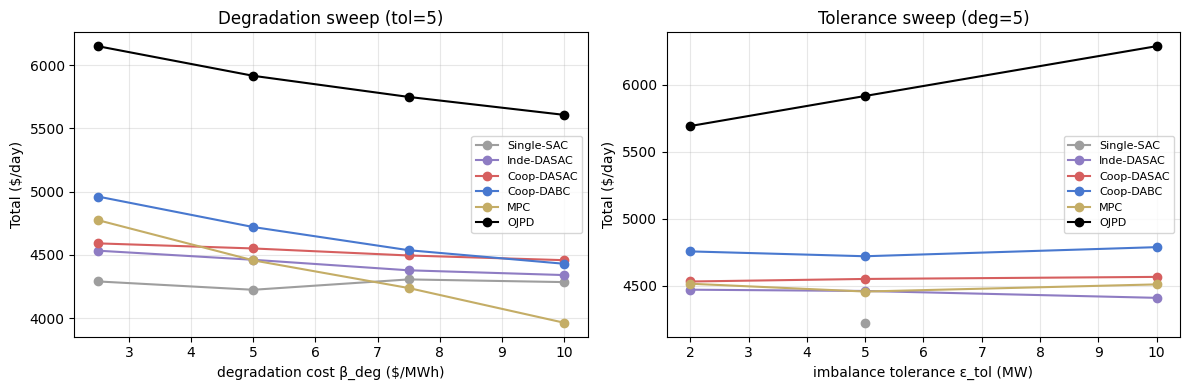

In [6]:
# 시각화: 설정별 Total (원고 Key findings의 두 경계 확인용)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
methods = ["Single-SAC", "Inde-DASAC", "Coop-DASAC", "Coop-DABC", "MPC", "OJPD"]
colors = {"Single-SAC": "#9E9E9E", "Inde-DASAC": "#8E7CC3", "Coop-DASAC": "#D65F5F",
          "Coop-DABC": "#4878CF", "MPC": "#C4AD66", "OJPD": "black"}
degs = [2.5, 5.0, 7.5, 10.0]
for name in methods:
    y = [(res[(d, 5.0)].get(name)[3] if name in res[(d, 5.0)] else
          mpc_row(d, 5.0)[3] if name == "MPC" else
          ojpd[(d, 5.0)][3] if name == "OJPD" else np.nan) for d in degs]
    axes[0].plot(degs, y, "o-", label=name, color=colors[name])
axes[0].set_xlabel("degradation cost β_deg ($/MWh)"); axes[0].set_title("Degradation sweep (tol=5)")
tols = [2.0, 5.0, 10.0]
for name in methods:
    y = [(res[(5.0, t)].get(name)[3] if name in res[(5.0, t)] else
          mpc_row(5.0, t)[3] if name == "MPC" else
          ojpd[(5.0, t)][3] if name == "OJPD" else np.nan) for t in tols]
    axes[1].plot(tols, y, "o-", label=name, color=colors[name])
axes[1].set_xlabel("imbalance tolerance ε_tol (MW)"); axes[1].set_title("Tolerance sweep (deg=5)")
for ax in axes:
    ax.set_ylabel("Total ($/day)"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()
